In [1]:
#importing and adding essential libraries and importing the csv file
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Telco-Customer-Churn.csv")

DATA CLEANING , EDA & FEATURE ENGINEERING

In [2]:
df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#for viewing all the columns we can use this function 
pd.set_option("display.max_columns", None)

In [5]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
#droping the colum name customerID as its not affecting the churn
df = df.drop(columns = ["customerID"])

In [8]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [9]:
#checking unique value for all the non-numeric columns

numerical_features_list = ["tenure" , "MonthlyCharges" , "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50) #----------this is to seprate out and for presenting the unique columns neatly

gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup <ArrowStringArray>
['Yes', 

In [10]:
#cheking for the null values in the dataset
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
#Converting the TotalCharges column in to a float

df[df["TotalCharges"]== " "]
len(df[df["TotalCharges"]== " "])

11

In [12]:
df["TotalCharges"] = df["TotalCharges"].replace({" ":"0.0"}) #--- here where the key is " " thier we are taking value 0.0
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [13]:
#checking through
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [14]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [15]:
#removed the duplicate values
print(df.duplicated().sum())

22


In [16]:
df = df.drop_duplicates()

In [17]:
print(df.duplicated().sum())

0


In [18]:
df.shape

(7021, 20)

In [19]:
# replaing the no internet service with no

df.replace("No internet service","No", inplace = True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [20]:
# similarly for the No phone Service replace it with No

df.replace("No phone service","No",inplace = True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [21]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [22]:
#Making the column which only have (Yes and No) into the 1 and 0

yes_no_columns = [
    'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV',
    'StreamingMovies', 'PaperlessBilling',
    'Churn'
]

for col in yes_no_columns:
    df[col] = df[col].replace({'Yes': 1, 'No': 0}).astype(int)

In [23]:
for col in df.columns:
    print(col, df[col].unique())

gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen [0 1]
Partner [1 0]
Dependents [0 1]
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService [0 1]
MultipleLines [0 1]
InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity [0 1]
OnlineBackup [1 0]
DeviceProtection [0 1]
TechSupport [0 1]
StreamingTV [0 1]
StreamingMovies [0 1]
Contract <ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaperlessBilling [1 0]
PaymentMethod <ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges [  29.85 1889.5   108.15 ...  346.45  306.6  6

In [24]:
#To convert the feature having more than two different type of values which are in text/str

df = pd.get_dummies(
    df,
    columns=["PaymentMethod", "InternetService", "Contract"],
    dtype=int
)

df.head(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year
0,Female,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,0,0,1,0,1,0,0,1,0,0
1,Male,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,0,0,0,1,1,0,0,0,1,0
2,Male,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,1,1,0,0,1,0,0
3,Male,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,1,0,0,0,1,0,0,0,1,0


In [25]:
#checking all data is in numerical format 
df.dtypes

gender                                         str
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
PaymentMethod_Bank transfer (automatic)      int64
PaymentMethod_Credit card (automatic)        int64
PaymentMethod_Electronic check 

In [26]:
#making the large values in to the range of [0-1]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = ["tenure", "MonthlyCharges", "TotalCharges"]

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [27]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year
0,Female,0,1,0,0.013889,0,0,0,1,0,0,0,0,1,0.115423,0.003437,0,0,0,1,0,1,0,0,1,0,0
1,Male,0,0,0,0.472222,1,0,1,0,1,0,0,0,0,0.385075,0.217564,0,0,0,0,1,1,0,0,0,1,0
2,Male,0,0,0,0.027778,1,0,1,1,0,0,0,0,1,0.354229,0.012453,1,0,0,0,1,1,0,0,1,0,0
3,Male,0,0,0,0.625000,0,0,1,0,1,1,0,0,0,0.239303,0.211951,0,1,0,0,0,1,0,0,0,1,0
4,Female,0,0,0,0.027778,1,0,0,0,0,0,0,0,1,0.521891,0.017462,1,0,0,1,0,0,1,0,1,0,0


GRAPHICAL REPERSENATION OF THE DATA

In [28]:
#Here we have defined a histogram plot so that we can use it multiple times 

def plot_histogram(df, column_name):
        
  plt.figure(figsize=(5, 3))                                        #defining the size of the figure
  sns.histplot(df[column_name], kde=True)                          #creating a histogram with the seaborn liabrary
  plt.title(f"Distribution of {column_name}")                      #giving the title

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

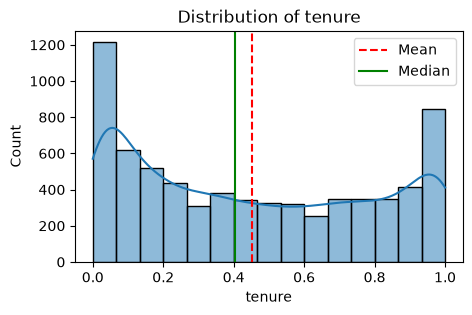

In [29]:
plot_histogram(df, "tenure")

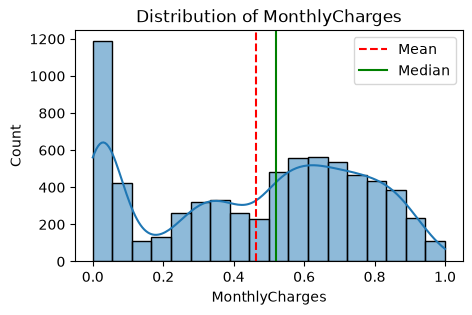

In [30]:
plot_histogram(df, "MonthlyCharges")

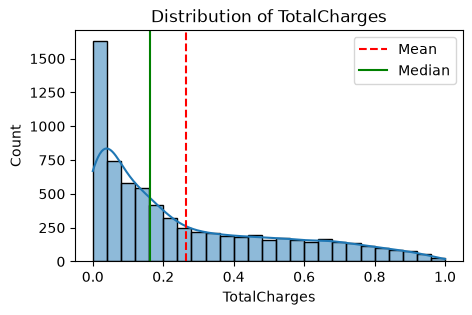

In [31]:
plot_histogram(df, "TotalCharges")

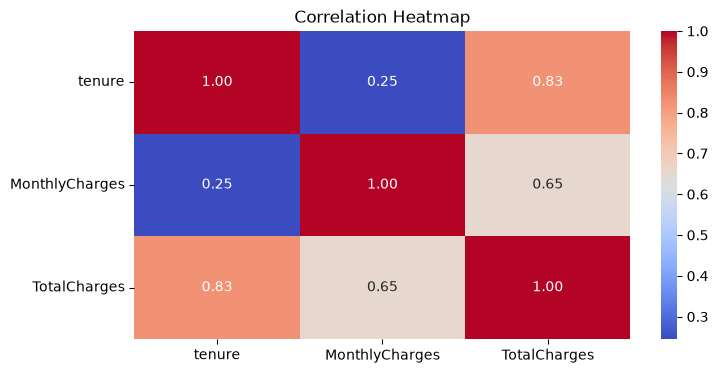

In [32]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
#defining the correlation inside the function
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

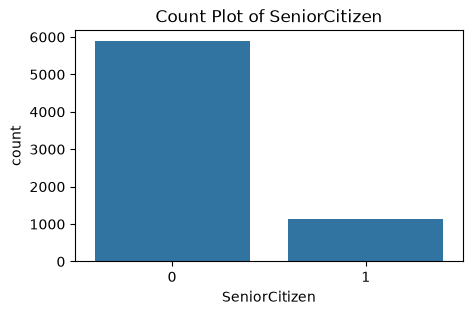

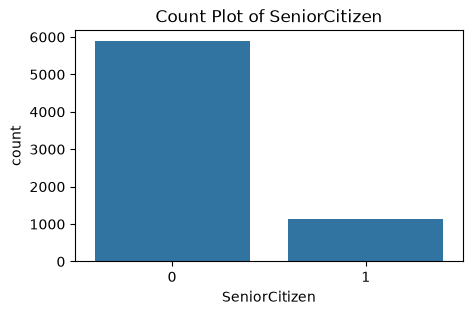

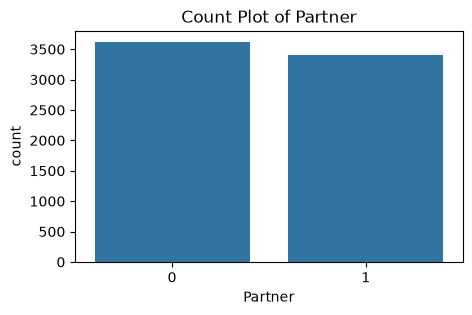

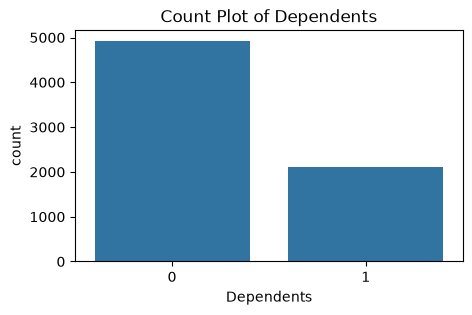

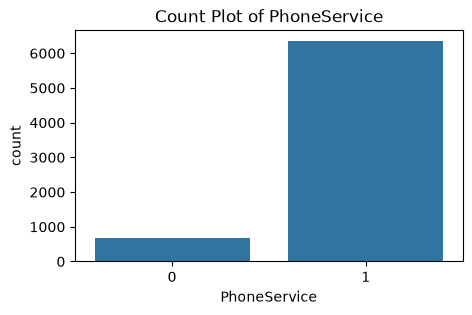

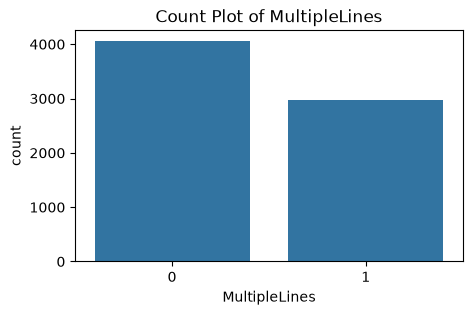

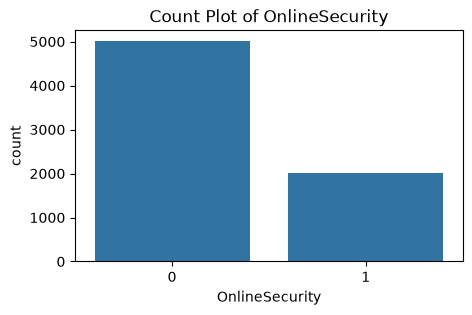

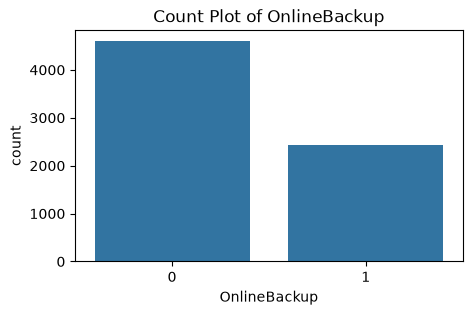

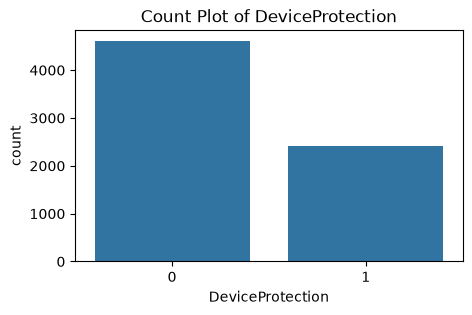

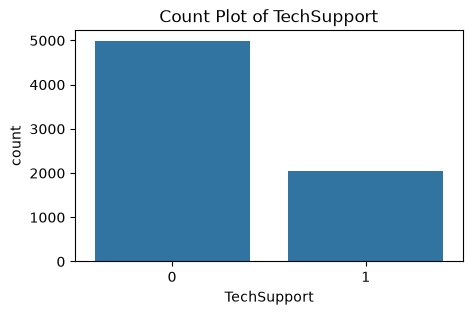

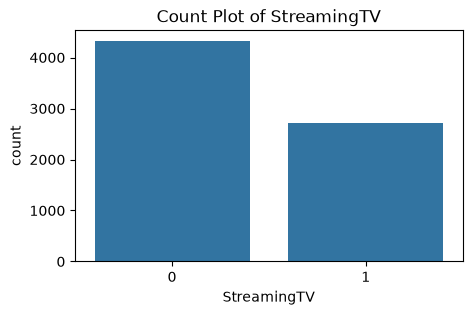

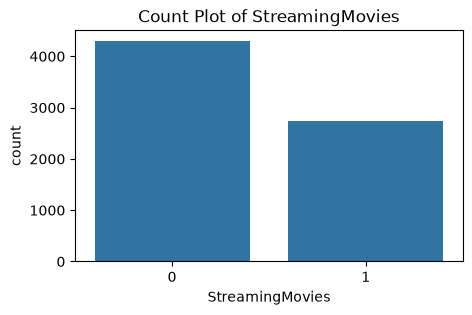

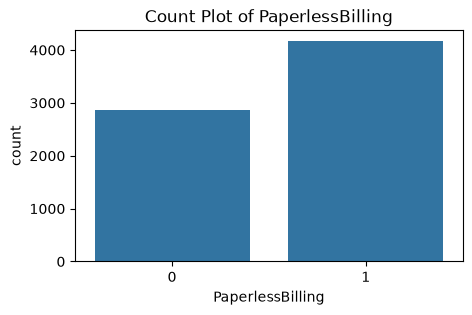

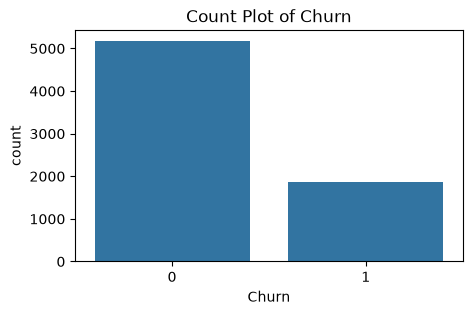

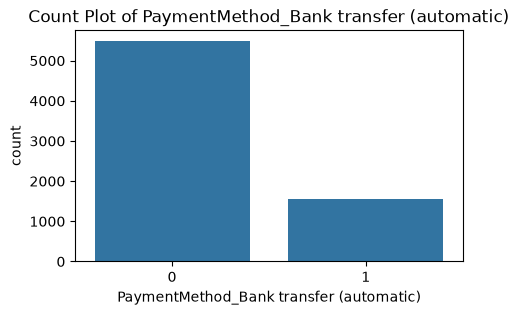

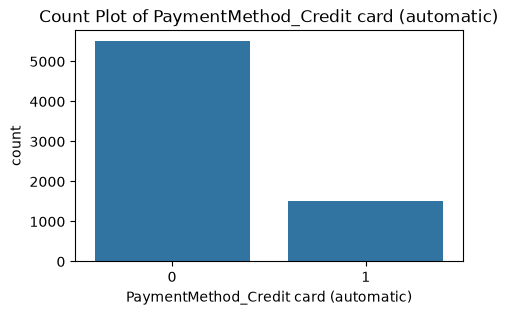

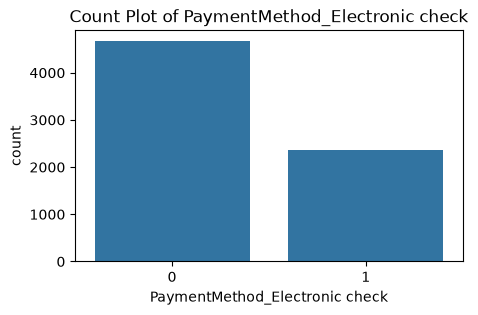

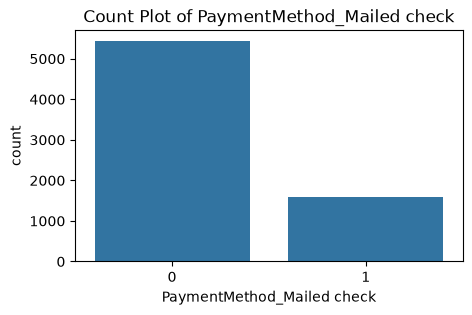

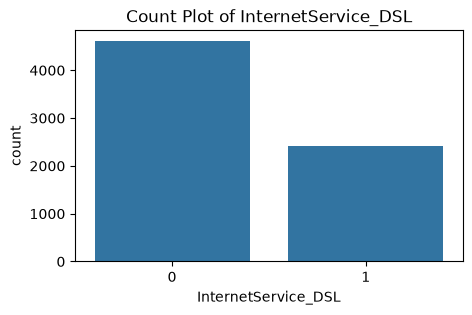

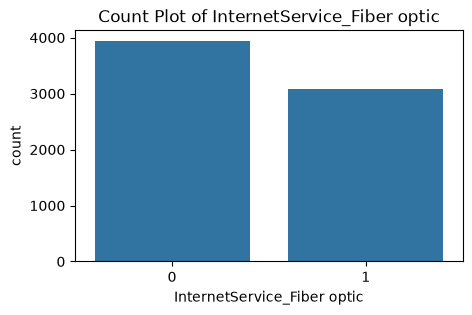

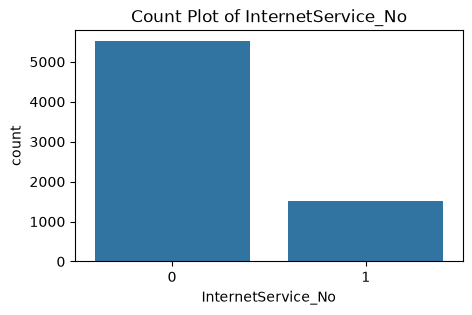

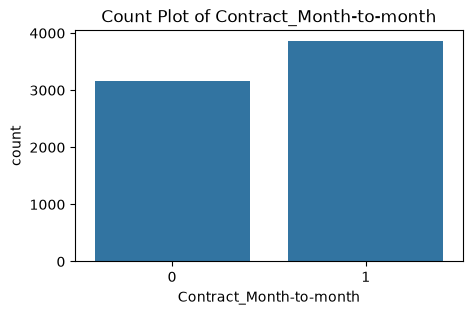

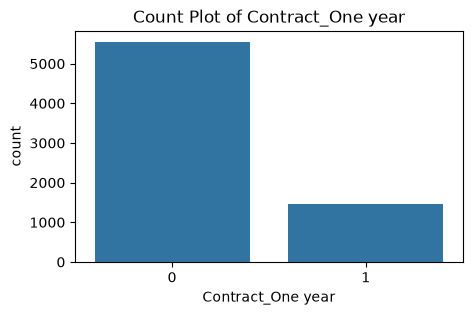

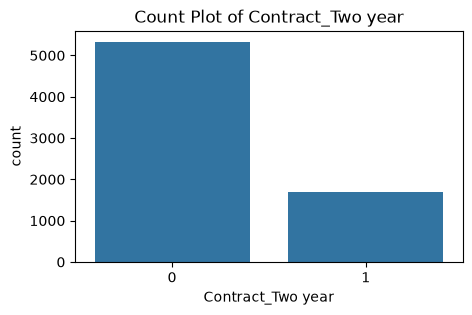

In [33]:
# Getting all integer columns
int_cols = df.select_dtypes(include="int64").columns.to_list()
# Adding SeniorCitizen to the list
int_cols = ["SeniorCitizen"] + int_cols
#Creating the loop for count plot for all these columns
for col in int_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

APPLYING SIGMOID AND LOG-LOSS FUNCTION TO IT 

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

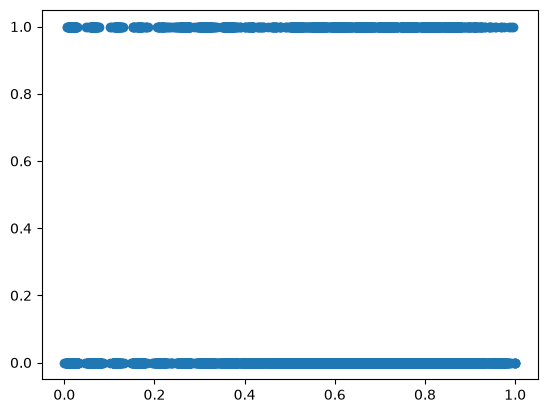

In [35]:
import matplotlib.pyplot as plt
plt.scatter(df["MonthlyCharges"], df["Churn"])
plt.show()

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train , X_test , y_train , y_test = train_test_split(df[['MonthlyCharges']] , df["Churn"] , test_size = 0.1 )

In [38]:
X_test

,MonthlyCharges
3948,0.702985
5348,0.222886
1016,0.615423
5704,0.682587
3909,0.012935
...,...
3420,0.509950
535,0.709453
1464,0.464677
4561,0.373134


In [39]:
X_train

,MonthlyCharges
1107,0.059701
3282,0.838308
3277,0.017413
6979,0.059204
6083,0.061194
...,...
5812,0.524876
4813,0.811443
2776,0.557711
5520,0.656716


In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
model = LogisticRegression()

In [42]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [43]:
model.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [44]:
model.score(X_test , y_test)

0.7553342816500711

In [45]:
print(model.coef_)
print(model.intercept_)

[[1.52053037]]
[-1.76785528]


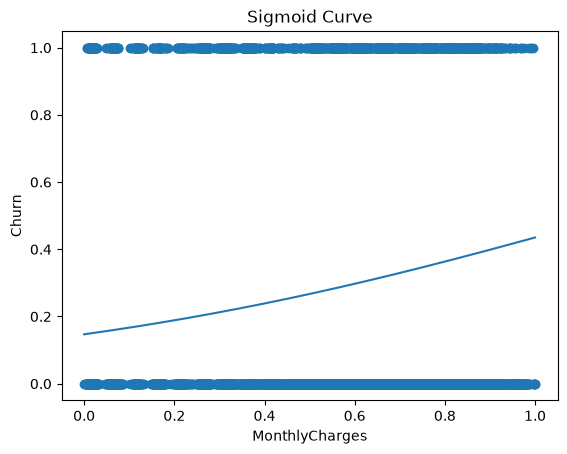

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x = df["MonthlyCharges"].values
y = df["Churn"].values

z = 1.49692561 * x + (-1.75798552)
y_pred = sigmoid(z)

idx = np.argsort(x)

plt.scatter(x, y)
plt.plot(x[idx], y_pred[idx])

plt.xlabel("MonthlyCharges")
plt.ylabel("Churn")
plt.title("Sigmoid Curve")
plt.show()

In [47]:
model.predict_proba(X_test)

array([[0.66795385, 0.33204615],
       [0.80673782, 0.19326218],
       [0.69679584, 0.30320416],
       ...,
       [0.74293897, 0.25706103],
       [0.76861251, 0.23138749],
       [0.82138816, 0.17861184]], shape=(703, 2))

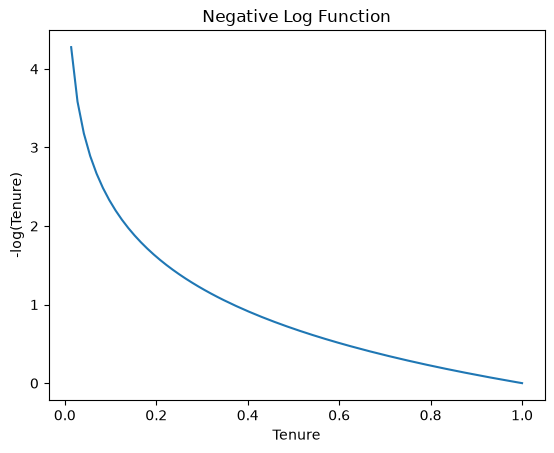

In [48]:
df = df.drop(df[df["tenure"] == 0].index)

df2 = df[df["tenure"] > 0].sort_values("tenure")

p = df2["tenure"] / df2["tenure"].max()

plt.plot(
    df2["tenure"],
    -1 * np.log(p)
)

plt.xlabel("Tenure")
plt.ylabel("-log(Tenure)")
plt.title("Negative Log Function")
plt.show()

C:\Users\Ayush\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


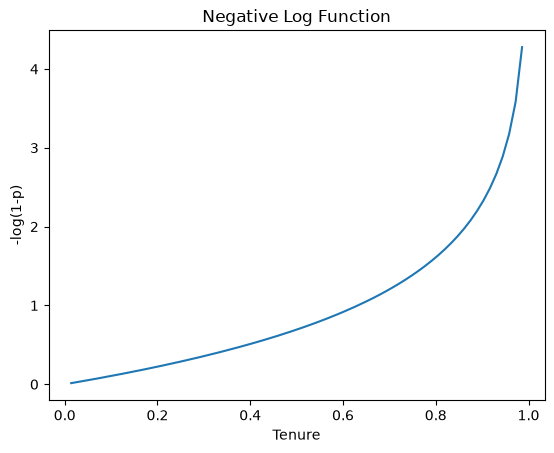

In [49]:
plt.plot(
    df2["tenure"],
    -np.log(1 - p) 
)

plt.xlabel("Tenure")
plt.ylabel("-log(1-p)")
plt.title("Negative Log Function")

plt.show()

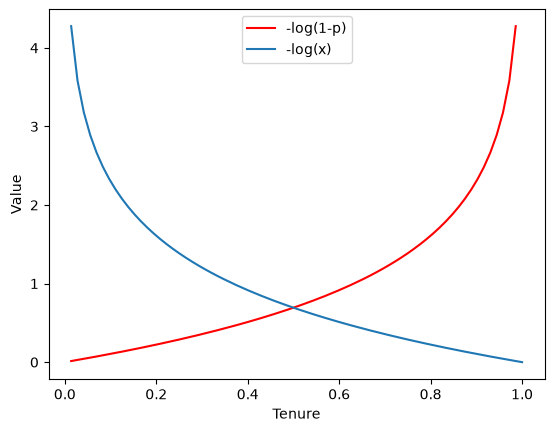

In [50]:
plt.plot(df2["tenure"], -np.log(1 - p), 'r', label='-log(1-p)')
plt.plot(df2["tenure"], -np.log(df2["tenure"]), label='-log(x)')

plt.xlabel("Tenure")
plt.ylabel("Value")
plt.legend()

plt.show()

In [51]:
x = df["tenure"].values
y = (df["Churn"] == "Yes").astype(int).values

w = 0
b = 0

learning_rate = 0.001
epochs = 1000

losses = []

for i in range(epochs):

    z = w * x + b

    y_pred = 1 / (1 + np.exp(-z))

    loss = -np.mean(
        y * np.log(y_pred + 1e-15) +
        (1 - y) * np.log(1 - y_pred + 1e-15)
    )

    losses.append(loss)

    dw = np.mean((y_pred - y) * x)
    db = np.mean(y_pred - y)

    w = w - learning_rate * dw
    b = b - learning_rate * db

print("Weight:", w)
print("Bias:", b)

Weight: -0.19259832179397648
Bias: -0.4326918377409727


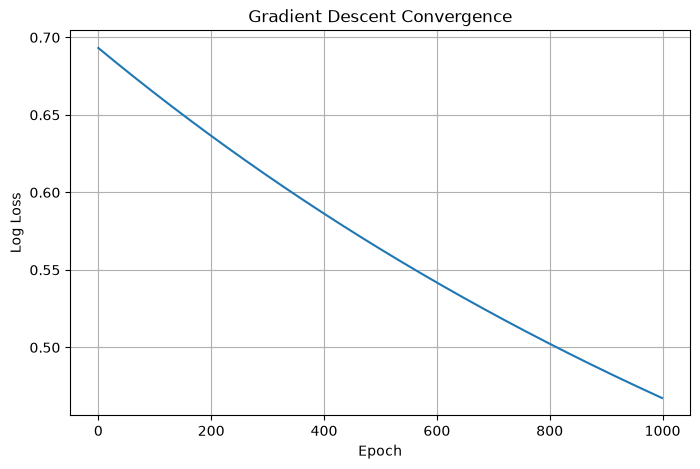

In [52]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()

In [53]:
import tensorflow as tf
from tensorflow import keras


def ANN(X_train, X_test, y_train, y_test):

    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(10, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        verbose=1
    )

    loss, accuracy = model.evaluate(X_test, y_test)

    print("Loss:", loss)
    print("Accuracy:", accuracy)

    y_preds = model.predict(X_test)
    y_preds = np.round(y_preds)

    return history, model

In [54]:
df = pd.get_dummies(df, columns=["gender"], drop_first=True)

In [55]:
df.dtypes

SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
PaymentMethod_Bank transfer (automatic)      int64
PaymentMethod_Credit card (automatic)        int64
PaymentMethod_Electronic check               int64
PaymentMethod_Mailed check     

In [56]:
print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'gender_Male'],
      dtype='str')


In [57]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [58]:
X = pd.get_dummies(X, drop_first=True)

In [59]:
print(X.shape)
print(y.shape)

(7010, 26)
(7010,)


In [60]:
X_train , X_test ,y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_sm, y_sm = smote.fit_resample(X, y)

print(y_sm.value_counts())

Churn
0    5153
1    5153
Name: count, dtype: int64


Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7470 - loss: 0.5142 
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7837 - loss: 0.4498   
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7896 - loss: 0.4370   
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7940 - loss: 0.4312   
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7923 - loss: 0.4293 
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7967 - loss: 0.4272   
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7976 - loss: 0.4263  
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7981 - loss: 0.4251 
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7976 - loss: 0.4248   
Epoch 10/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7994 - loss: 0.4245 
Epoch 11/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7990 - loss: 0.4235 
Epoch 12/100
176/17

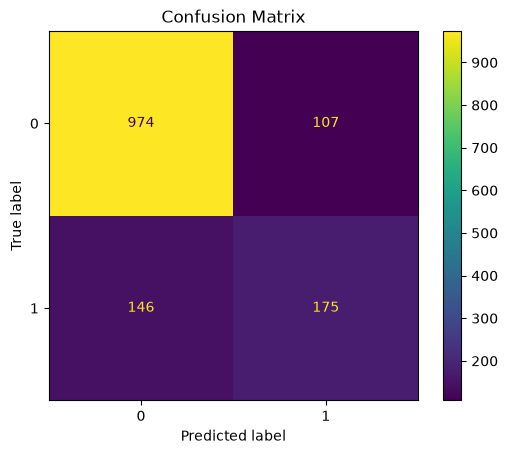

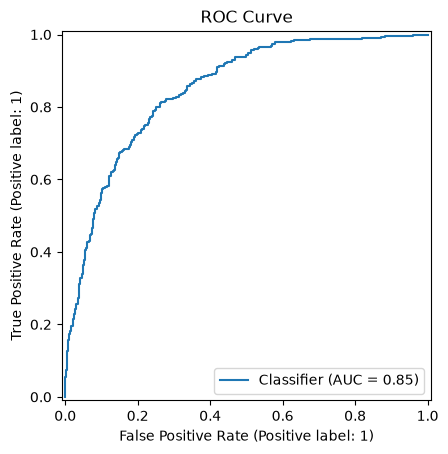

In [62]:
history, ann_model = ANN(X_train, X_test, y_train, y_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

y_proba = ann_model.predict(X_test).ravel()
y_pred = (y_proba >= 0.5).astype(int)
y_true = np.array(y_test)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("ROC AUC:", roc_auc_score(y_true, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_true, y_proba)
plt.title("ROC Curve")
plt.show()

In [63]:
custom_acc = accuracy_score(y_test, y_pred)
custom_prec = precision_score(y_test, y_pred)
custom_rec = recall_score(y_test, y_pred)
custom_f1 = f1_score(y_test, y_pred)
custom_roc = roc_auc_score(y_test, y_proba)

In [64]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Custom Logistic Regression"],
    "Accuracy": [round(custom_acc, 4)],
    "Precision": [round(custom_prec, 4)],
    "Recall": [round(custom_rec, 4)],
    "F1 Score": [round(custom_f1, 4)],
    "ROC-AUC": [round(custom_roc, 4)]
})

print(results)

                        Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Custom Logistic Regression    0.8195     0.6206  0.5452    0.5804   0.8492


In [67]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame({
    "Model": ["Custom Logistic Regression"],
    "Accuracy": [round(custom_acc(y_test, y_pred), 4)],
    "Precision": [round(precision_score(y_test, y_pred), 4)],
    "Recall": [round(recall_score(y_test, y_pred), 4)],
    "F1 Score": [round(f1_score(y_test, y_pred), 4)],
    "ROC-AUC": [round(roc_auc_score(y_test, y_proba), 4)]
})

print(results)

TypeError: 'float' object is not callable

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

In [ ]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

In [ ]:
results = pd.DataFrame({
    "Model": ["Custom LR", "Sklearn LR"],
    "Accuracy": [round(custom_acc, 4), round(acc, 4)],
    "Precision": [round(custom_prec, 4), round(prec, 4)],
    "Recall": [round(custom_rec, 4), round(rec, 4)],
    "F1 Score": [round(custom_f1, 4), round(f1, 4)],
    "ROC-AUC": [round(custom_roc, 4), round(roc, 4)]
})

results

In [ ]:
import pandas as pd

# Create a DataFrame containing feature names and their corresponding
# Logistic Regression coefficients (weights)
feature_importance = pd.DataFrame({
    
    # Names of all input features used to train the model
    "Feature": X_train.columns,
    
    # Coefficients learned by Logistic Regression
    # lr.coef_[0] returns the weights for the binary classification model
    "Coefficient": lr.coef_[0]
})

# Sort features by coefficient value in descending order
# Highest positive coefficients appear at the top
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

# Interpretation:
# Positive coefficient  -> Increases probability of churn
# Negative coefficient  -> Decreases probability of churn
# Larger absolute value -> Stronger impact on prediction


# Display the sorted feature importance table
print(feature_importance)

In [ ]:
import pandas as pd
import numpy as np

input_data = {
    'gender': 'Female',
    'SeniorCitizen': 1,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 100,
    'TotalCharges': 100
}

# Convert to DataFrame
input_df = pd.DataFrame([input_data])

# Same preprocessing as training
input_df = pd.get_dummies(input_df, drop_first=True)

# Match ANN training columns
input_df = input_df.reindex(
    columns=X_train.columns,
    fill_value=0
)

# ANN prediction
churn_prob = float(ann_model.predict(input_df, verbose=0)[0][0])

print("Prediction:", "Churn" if churn_prob >= 0.5 else "No Churn")
print("Prediction Probability:", [[round(1-churn_prob, 4), round(churn_prob, 4)]])

In [ ]:
y_proba = ann_model.predict(X_test, verbose=0)

print("Min:", y_proba.min())
print("Max:", y_proba.max())
print("Mean:", y_proba.mean())

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_proba))

In [ ]:
y_pred = (y_proba >= 0.5).astype(int)

print(np.unique(y_pred, return_counts=True))

In [ ]:
print(history.history['accuracy'][-1])
print(history.history['loss'][-1])

In [ ]:
ann_model.save("churn_ann_model.keras")